# Day 63: Hyperparameter Tuning — GridSearchCV
**Phase 4 · Machine Learning** | Dataset: FC Lahore Lions matches (synthetic, seed = 42)

## Objective
By the end of this notebook I should be able to:
- Explain **parameters vs hyperparameters**
- Set up and run `GridSearchCV` with a `param_grid` (for example `max_depth` x `n_estimators`)
- Read `best_params_`, `best_score_`, `cv_results_` and use the **refit** `best_estimator_`
- Tune a **pipeline** (scaler + model) using the `step__param` naming
- Judge honestly whether tuning actually helped, and avoid tuning on the test set

## Imports

In [1]:
# numpy and pandas for data
import numpy as np
import pandas as pd

# matplotlib for charts
import matplotlib.pyplot as plt

# models and tools
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV

plt.rcParams["axes.grid"] = True

## Theory
- **Parameters** are **learned from the data** while fitting (logistic regression weights, the split rules inside a tree).
- **Hyperparameters** are **set by you before fitting** (`max_depth`, `n_estimators`, K in KNN, `C` in logistic regression).
- Default hyperparameters are a reasonable start, but rarely the best for your data.
- **GridSearchCV** tries **every combination** in a grid. For each combination it runs K-fold cross-validation (Day 62) and keeps the mean score.
  - Number of fits = (number of combinations) x (number of folds). A `3 x 3` grid with 5 folds = 45 fits.
  - Grids grow fast: every extra hyperparameter multiplies the total.
- **`refit=True` (default):** after the search, the best combination is retrained on the **whole training set** and stored as `best_estimator_`.
- **Useful attributes:** `best_params_`, `best_score_` (mean CV score of the winner), `best_estimator_`, `cv_results_` (every combination).
- **Rules that keep it honest:**
  1. Tune with CV on the **training set only**. Never look at the test set while tuning.
  2. Use the test set **once**, at the very end.
  3. `best_score_` is the best of many tries, so it can be a little optimistic. If several combinations are within one std of each other, the "winner" may be luck.
- **Pipelines:** to tune a step inside a pipeline, name the parameter `stepname__param`, for example `logisticregression__C`.

**Football picture:** hyperparameters are the coach's tactical settings (formation, pressing line, tempo). You try each setup over 5 different matches (CV), keep the results, and only then pick the setup for the final. If three setups score almost the same, do not pretend one of them is a genius plan.

## Example 1: Parameters vs Hyperparameters, and a Baseline

In [2]:
# Synthetic data: 500 matches (same dataset as Days 59 to 62)
rng = np.random.default_rng(42)                      # seed = 42 so results repeat
n_matches = 500

shots = rng.integers(0, 13, size=n_matches)          # shots on target
possession = rng.integers(35, 66, size=n_matches)    # possession %
pass_accuracy = rng.integers(70, 93, size=n_matches) # pass accuracy %
home_game = rng.integers(0, 2, size=n_matches)       # 1 = home, 0 = away
opponent_rank = rng.integers(1, 21, size=n_matches)  # 1 = strongest opponent
kickoff_hour = rng.integers(12, 22, size=n_matches)  # NOT linked to the result, on purpose

z = (0.45 * shots + 0.04 * (possession - 50) + 0.7 * home_game
     + 0.10 * (opponent_rank - 10) - 3.0)
won = rng.binomial(1, 1 / (1 + np.exp(-z)))

df = pd.DataFrame({
    "match_id": np.arange(1, n_matches + 1),
    "shots_on_target": shots, "possession_pct": possession,
    "pass_accuracy_pct": pass_accuracy, "home_game": home_game,
    "opponent_rank": opponent_rank, "kickoff_hour": kickoff_hour, "won": won
})

# Save next to the notebook, then read it back
df.to_csv("day_63_fc_lahore_lions_matches.csv", index=False)
df = pd.read_csv("day_63_fc_lahore_lions_matches.csv")

X = df.drop(columns=["match_id", "won"])
y = df["won"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print("Train:", len(X_train), "| Test:", len(X_test))

Train: 375 | Test: 125


In [3]:
# Parameters are LEARNED. Hyperparameters are SET BY ME.
X_train_s = StandardScaler().fit_transform(X_train)

lr = LogisticRegression(C=1.0, max_iter=1000)     # C: a hyperparameter I chose
lr.fit(X_train_s, y_train)

print("Hyperparameter C (set by me):", lr.C)
print("Learned weights (coef_):     ", lr.coef_.round(2))
print("Feature order:", list(X.columns))

Hyperparameter C (set by me): 1.0
Learned weights (coef_):      [[1.7  0.2  0.   0.18 0.36 0.18]]
Feature order: ['shots_on_target', 'possession_pct', 'pass_accuracy_pct', 'home_game', 'opponent_rank', 'kickoff_hour']


In [4]:
# Baseline: a forest with default settings. Score it with 5-fold CV on the TRAINING set.
default_rf = RandomForestClassifier(random_state=42)     # default: no depth limit, 100 trees
default_cv = cross_val_score(default_rf, X_train, y_train, cv=5)

print("Default forest CV scores:", default_cv.round(3))
print("Mean +/- std:", round(default_cv.mean(), 3), "+/-", round(default_cv.std(), 3))

Default forest CV scores: [0.76  0.787 0.787 0.813 0.813]
Mean +/- std: 0.792 +/- 0.02


## Example 2: GridSearchCV with a Random Forest

In [5]:
# The grid: 3 depths x 3 tree counts = 9 combinations
param_grid = {
    "max_depth": [3, 5, 7],
    "n_estimators": [50, 100, 200],
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,                    # 5-fold CV for every combination
    scoring="accuracy",
    n_jobs=-1,               # use all CPU cores
)
grid.fit(X_train, y_train)   # trains on the TRAINING set only

n_combos = len(grid.cv_results_["params"])
print(n_combos, "combinations x 5 folds =", n_combos * 5, "fits (plus 1 final refit)")

9 combinations x 5 folds = 45 fits (plus 1 final refit)


In [6]:
# The winner
print("Best params:", grid.best_params_)
print("Best mean CV accuracy:", round(grid.best_score_, 3))
print("Default forest CV accuracy:", round(default_cv.mean(), 3))

Best params: {'max_depth': 5, 'n_estimators': 200}
Best mean CV accuracy: 0.789
Default forest CV accuracy: 0.792


In [7]:
# Every combination, ranked (cv_results_ holds the whole story)
res = pd.DataFrame(grid.cv_results_)
res["depth"] = res["param_max_depth"]
res["trees"] = res["param_n_estimators"]

table = res[["depth", "trees", "mean_test_score", "std_test_score",
             "rank_test_score", "mean_fit_time"]]
print(table.sort_values("rank_test_score").round(3).to_string(index=False))

 depth  trees  mean_test_score  std_test_score  rank_test_score  mean_fit_time
     5    200            0.789           0.028                1          0.192
     3     50            0.787           0.022                2          0.045
     5     50            0.787           0.036                2          0.048
     3    100            0.787           0.022                2          0.089
     7     50            0.787           0.033                2          0.052
     3    200            0.784           0.018                6          0.181
     7    100            0.779           0.036                7          0.104
     7    200            0.776           0.027                8          0.216
     5    100            0.773           0.024                9          0.096


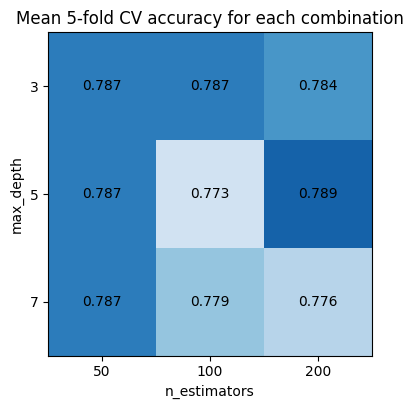

In [8]:
# Chart 1: heatmap of mean CV accuracy across the grid
pivot = res.pivot(index="depth", columns="trees", values="mean_test_score").astype(float)

fig, ax = plt.subplots(figsize=(6.5, 4.2))
im = ax.imshow(pivot.values, cmap="Blues", vmin=pivot.values.min() - 0.005, vmax=pivot.values.max() + 0.005)
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        ax.text(j, i, f"{pivot.values[i, j]:.3f}", ha="center", va="center")
ax.set_xlabel("n_estimators")
ax.set_ylabel("max_depth")
ax.set_title("Mean 5-fold CV accuracy for each combination")
ax.grid(False)
plt.savefig("images/grid_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

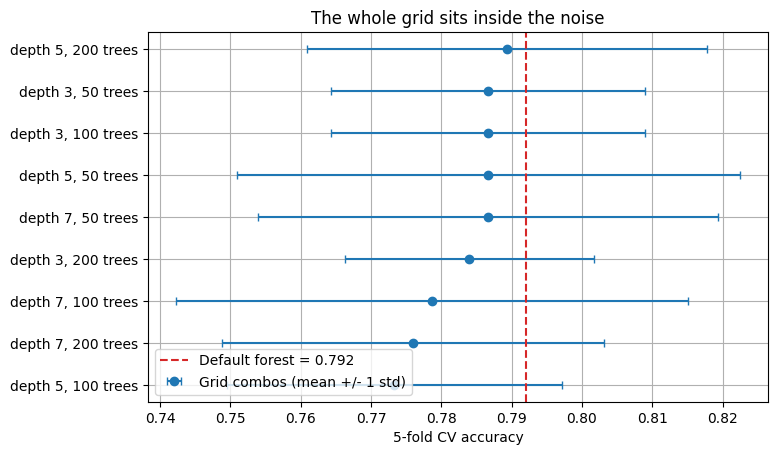

In [9]:
# Chart 2: all 9 combinations with their +/- 1 std, against the default forest
ranked = res.sort_values("rank_test_score", kind="stable").reset_index(drop=True)
labels = [f"depth {d}, {t} trees" for d, t in zip(ranked["depth"], ranked["trees"])]

plt.figure(figsize=(8, 4.8))
plt.errorbar(ranked["mean_test_score"], range(len(ranked)), xerr=ranked["std_test_score"],
             fmt="o", capsize=3, label="Grid combos (mean +/- 1 std)")
plt.axvline(default_cv.mean(), color="tab:red", linestyle="--",
            label=f"Default forest = {default_cv.mean():.3f}")
plt.yticks(range(len(ranked)), labels)
plt.gca().invert_yaxis()
plt.xlabel("5-fold CV accuracy")
plt.title("The whole grid sits inside the noise")
plt.legend(loc="lower left")
plt.savefig("images/grid_scores_with_std.png", dpi=150, bbox_inches="tight")
plt.show()

### 2B. Refit, then use the test set ONCE

In [10]:
# refit=True (default): the best combination was retrained on ALL the training rows
best_rf = grid.best_estimator_
print("Type:", type(best_rf).__name__, "| max_depth:", best_rf.max_depth, "| n_estimators:", best_rf.n_estimators)

# The test set is used once, now that the tuning is finished
default_rf.fit(X_train, y_train)
print("Default forest test accuracy:", round(default_rf.score(X_test, y_test), 3))
print("Tuned forest test accuracy:  ", round(best_rf.score(X_test, y_test), 3))
print("Test rows:", len(X_test), "| one match =", round(1 / len(X_test), 3), "accuracy")

Type: RandomForestClassifier | max_depth: 5 | n_estimators: 200
Default forest test accuracy: 0.76
Tuned forest test accuracy:   0.768
Test rows: 125 | one match = 0.008 accuracy


### 2C. Is the 'winner' really better? The one-standard-deviation check

In [11]:
# Which combinations are within 1 std of the best one?
best_row = res.loc[res["mean_test_score"].idxmax()]
cutoff = best_row["mean_test_score"] - best_row["std_test_score"]
close = res[res["mean_test_score"] >= cutoff]

print("Best mean:", round(best_row["mean_test_score"], 3), "| std:", round(best_row["std_test_score"], 3))
print("Cutoff (best - 1 std):", round(cutoff, 3))
print("Combinations within 1 std of the best:", len(close), "of", len(res))

# When many are tied, prefer the cheapest one (fastest to fit)
cheapest = close.sort_values("mean_fit_time").iloc[0]
print("\nCheapest close combo: depth", cheapest["depth"], "| trees", cheapest["trees"],
      "| fit time", round(cheapest["mean_fit_time"], 3), "s (best combo:", round(best_row["mean_fit_time"], 3), "s)")

Best mean: 0.789 | std: 0.028
Cutoff (best - 1 std): 0.761
Combinations within 1 std of the best: 9 of 9

Cheapest close combo: depth 3 | trees 50 | fit time 0.045 s (best combo: 0.192 s)


## Example 3: Tuning a Pipeline (scaler + Logistic Regression)

In [12]:
# Parameter name inside a pipeline = step name + double underscore + parameter
pipe = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
print("Pipeline step names:", list(pipe.named_steps))

c_values = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100]
grid_lr = GridSearchCV(pipe, {"logisticregression__C": c_values}, cv=5, scoring="accuracy")
grid_lr.fit(X_train, y_train)      # the scaler is re-fit inside every fold, so no leakage

print("Best params:", grid_lr.best_params_)
print("Best mean CV accuracy:", round(grid_lr.best_score_, 3))
print("Test accuracy:", round(grid_lr.score(X_test, y_test), 3))

Pipeline step names: ['standardscaler', 'logisticregression']


Best params: {'logisticregression__C': 0.001}
Best mean CV accuracy: 0.781
Test accuracy: 0.768


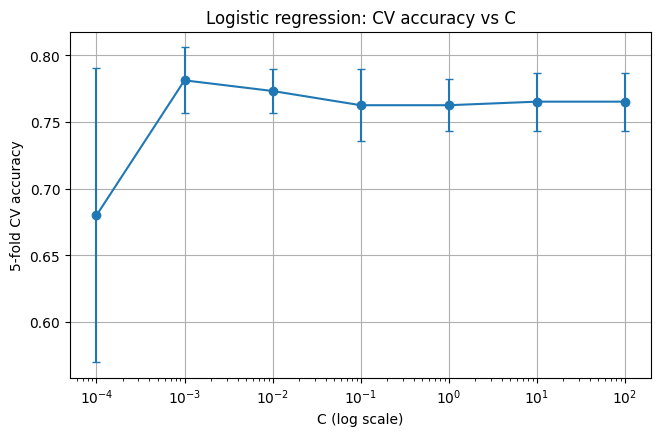

 param_logisticregression__C  mean_test_score  std_test_score
                       0.000            0.680           0.110
                       0.001            0.781           0.025
                       0.010            0.773           0.017
                       0.100            0.763           0.027
                       1.000            0.763           0.020
                      10.000            0.765           0.022
                     100.000            0.765           0.022


In [13]:
# Chart: CV accuracy against C (log scale)
lr_res = pd.DataFrame(grid_lr.cv_results_)

plt.figure(figsize=(7.5, 4.5))
plt.errorbar(c_values, lr_res["mean_test_score"], yerr=lr_res["std_test_score"], marker="o", capsize=3)
plt.xscale("log")
plt.xlabel("C (log scale)")
plt.ylabel("5-fold CV accuracy")
plt.title("Logistic regression: CV accuracy vs C")
plt.savefig("images/logistic_C_search.png", dpi=150, bbox_inches="tight")
plt.show()
print(lr_res[["param_logisticregression__C", "mean_test_score", "std_test_score"]].round(3).to_string(index=False))

## Practice Exercise
**Your turn (Practice).** Tune a **KNN pipeline** (Day 57) on `X_train` and `y_train`:
1. Build `make_pipeline(StandardScaler(), KNeighborsClassifier())`.
2. Grid: `n_neighbors` in `[3, 5, 7, 9, 11, 15, 21]` and `weights` in `["uniform", "distance"]`.
3. Use 5-fold CV, then print `best_params_`, `best_score_` and the **test** accuracy (once).
4. How many fits did the search run?

In [14]:
# Your attempt here

In [15]:
# Worked answer
knn_pipe = make_pipeline(StandardScaler(), KNeighborsClassifier())
knn_grid = {
    "kneighborsclassifier__n_neighbors": [3, 5, 7, 9, 11, 15, 21],
    "kneighborsclassifier__weights": ["uniform", "distance"],
}

grid_knn = GridSearchCV(knn_pipe, knn_grid, cv=5, scoring="accuracy", n_jobs=-1)
grid_knn.fit(X_train, y_train)

n_knn = len(grid_knn.cv_results_["params"])
print("Best params:", grid_knn.best_params_)
print("Best mean CV accuracy:", round(grid_knn.best_score_, 3))
print("Test accuracy:", round(grid_knn.score(X_test, y_test), 3))
print("Fits:", n_knn, "combinations x 5 folds =", n_knn * 5)

Best params: {'kneighborsclassifier__n_neighbors': 11, 'kneighborsclassifier__weights': 'distance'}
Best mean CV accuracy: 0.776
Test accuracy: 0.736
Fits: 14 combinations x 5 folds = 70


## Mini Challenge
**A bigger grid, judged honestly.** Search a wider forest grid with 5-fold CV on the training set:
- `max_depth`: `[3, 5, None]`
- `min_samples_leaf`: `[1, 3, 5, 10]`
- `max_features`: `["sqrt", None]`
- `n_estimators`: fixed at `100`

Then report: the number of combinations and fits, the best params, how many combinations are within 1 std of the best, the **fastest** of those, and the test accuracy of the best and of the fastest.

In [16]:
# Mini Challenge solution
wide_grid = {
    "max_depth": [3, 5, None],
    "min_samples_leaf": [1, 3, 5, 10],
    "max_features": ["sqrt", None],
}
wide = GridSearchCV(RandomForestClassifier(n_estimators=100, random_state=42),
                    wide_grid, cv=5, scoring="accuracy", n_jobs=-1)
wide.fit(X_train, y_train)

wide_res = pd.DataFrame(wide.cv_results_)
n_wide = len(wide_res)
print("Combinations:", n_wide, "| fits:", n_wide * 5)
print("Best params:", wide.best_params_)
print("Best mean CV accuracy:", round(wide.best_score_, 3))

top = wide_res.loc[wide_res["mean_test_score"].idxmax()]
close_wide = wide_res[wide_res["mean_test_score"] >= top["mean_test_score"] - top["std_test_score"]]
print("Within 1 std of the best:", len(close_wide), "of", n_wide)

fastest = close_wide.sort_values("mean_fit_time").iloc[0]
print("Fastest of those:", fastest["params"])

fast_model = RandomForestClassifier(n_estimators=100, random_state=42, **fastest["params"])
fast_model.fit(X_train, y_train)
print("\nTest accuracy, best combo:   ", round(wide.score(X_test, y_test), 3))
print("Test accuracy, fastest close:", round(fast_model.score(X_test, y_test), 3))

Combinations: 24 | fits: 120
Best params: {'max_depth': None, 'max_features': None, 'min_samples_leaf': 3}
Best mean CV accuracy: 0.795
Within 1 std of the best: 24 of 24
Fastest of those: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 10}

Test accuracy, best combo:    0.76
Test accuracy, fastest close: 0.744


## Summary
- **Parameters** are learned (logistic regression weights). **Hyperparameters** are set by you (`C`, `max_depth`, `n_estimators`).
- `GridSearchCV` tried all 9 forest combinations with 5-fold CV (45 fits plus a refit) and returned `best_params_`, `best_score_` and a refit `best_estimator_`.
- **Honest result:** the winner (`max_depth=5`, `n_estimators=200`) had a CV accuracy of 0.789, but the default forest scored 0.792, and all 9 grid combinations sat between 0.773 and 0.789, well inside one standard deviation. On the test set the tuned forest scored 0.768 vs 0.760 for the default, a difference of one match out of 125. **Tuning did not meaningfully help here**, because the score landscape is flat.
- A grid only searches what you put in it. The default forest (no depth limit) was not in the grid, and it did as well as anything in it.
- The one-std check showed that when combinations are tied, you can pick the cheapest one (a fraction of the fit time).
- In a **pipeline**, tune with `stepname__param`. The scaler is re-fit inside every fold, so there is no leakage.
- **Never tune on the test set.** Use CV on the training set, then look at the test set once.
- **Next: Day 64 — RandomizedSearchCV and practical tuning tips.**